<a href="https://colab.research.google.com/github/Prabhjot-kaur-tech/CIND820_Retail_sales_Analytics/blob/main/03_Milestone3_Initial_Results_RFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##CIND820- Milestone 3
# Retail Sales Analytics and Customer Purchasing Behaviour Analysis




In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Online_Retail_Raw_Data.xlsx to Online_Retail_Raw_Data (1).xlsx


#1. Upload Raw dataset

In [ ]:
df_raw = pd.read_excel("/content/Online_Retail_Raw_Data (1).xlsx")

print("Raw dataset shape:", df_raw.shape)
df_raw.head()

Raw dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


#2. Initial Dataset Exploration

In [ ]:
# Initial Dataset Exploration

print("\nDataset Shape:")
print(df_raw.shape)

print("\nDataset Information:")
df_raw.info()

print("\nColumn Names:")
print(df_raw.columns.tolist())

print("\nMissing Values:")
display(df_raw.isnull().sum())

print("\nDuplicate Rows:")
print(df_raw.duplicated().sum())

print("\nDescriptive Statistics:")
display(df_raw.describe())


Dataset Shape:
(541909, 8)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing Values:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0



Duplicate Rows:
5268

Descriptive Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"541,909.00",541909,"541,909.00","406,829.00"
mean,9.55,2011-07-04 13:34:57.156386048,4.61,"15,287.69"
min,"-80,995.00",2010-12-01 08:26:00,"-11,062.06","12,346.00"
25%,1.00,2011-03-28 11:34:00,1.25,"13,953.00"
50%,3.00,2011-07-19 17:17:00,2.08,"15,152.00"
75%,10.00,2011-10-19 11:27:00,4.13,"16,791.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,218.08,NaN,96.76,"1,713.60"


# 3.Data quality assessment

In [ ]:
# Data quality assessment

cancelled_invoices = df_raw["InvoiceNo"].astype(str).str.startswith("C").sum()
negative_quantity = (df_raw["Quantity"] < 0).sum()
zero_negative_price = (df_raw["UnitPrice"] <= 0).sum()
missing_customer = df_raw["CustomerID"].isnull().sum()
missing_description = df_raw["Description"].isnull().sum()
duplicates = df_raw.duplicated().sum()

quality_summary = pd.DataFrame({
    "Issue": [
        "Cancelled invoices",
        "Negative quantity records",
        "Zero or negative UnitPrice",
        "Missing CustomerID",
        "Missing Description",
        "Duplicate rows"
    ],
    "Records Identified": [
        cancelled_invoices,
        negative_quantity,
        zero_negative_price,
        missing_customer,
        missing_description,
        duplicates
    ]
})

quality_summary

,Issue,Records Identified
0,Cancelled invoices,9288
1,Negative quantity records,10624
2,Zero or negative UnitPrice,2517
3,Missing CustomerID,135080
4,Missing Description,1454
5,Duplicate rows,5268


#4. Data Cleaning

In [ ]:
# Data Cleaning
df_clean = df_raw.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove cancelled invoices
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

# Keep only valid positive quantity and price
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Convert date
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Create Revenue
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Create Month
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

print("Cleaned sales dataset shape:", df_clean.shape)
df_clean.head()

Cleaned sales dataset shape: (524878, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom,20.34,2010-12


#5. Customer level dataset for RFM

In [ ]:
#Customer level dataset for RFM
df_customer = df_clean.dropna(subset=["CustomerID"]).copy()

print("Customer-level dataset shape:", df_customer.shape)
print("Unique customers:", df_customer["CustomerID"].nunique())


Customer-level dataset shape: (392692, 10)
Unique customers: 4338


#6.  Feature Engineering for RFM Analysis
The cleaned customer-level dataset is used to engineer the three RFM variables:

- Recency: Days since the customer's most recent valid purchase.
- Frequency: Number of distinct valid invoices.
- Monetary: Total revenue generated by the customer.

These variables form the basis of the RFM customer segmentation model proposed in Milestone 2.

In [ ]:

analysis_date = df_customer["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [ ]:
rfm = df_customer.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (analysis_date - x.max()).days,

    "InvoiceNo": "nunique",

    "Revenue": "sum"

})

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
"12,346.00",326,1,"77,183.60"
"12,347.00",2,7,"4,310.00"
"12,348.00",75,4,"1,797.24"
"12,349.00",19,1,"1,757.55"
"12,350.00",310,1,334.40


In [ ]:
#display summary statistics
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69"
std,100.01,7.70,"8,985.23"
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,"1,660.60"
max,374.00,209.00,"280,206.02"


In [ ]:
#display RFM dataset shape
print("RFM Dataset Shape:", rfm.shape)

RFM Dataset Shape: (4338, 3)


#6.1 Recency Analysis





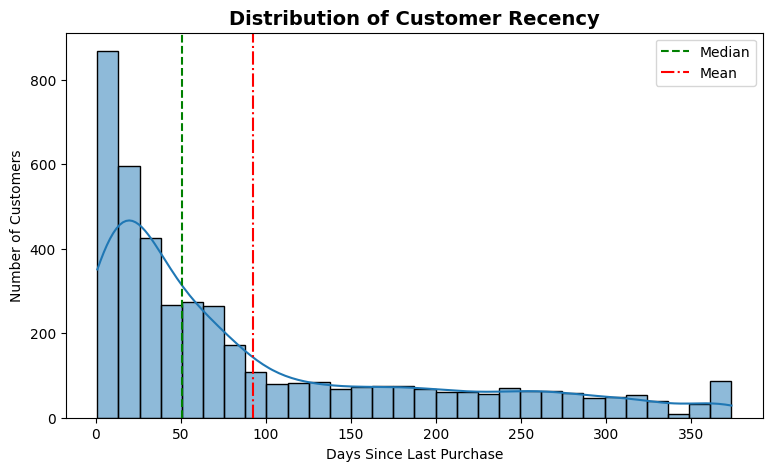

In [ ]:
# histogram
plt.figure(figsize=(9,5))

sns.histplot(rfm["Recency"], bins=30, kde=True)

plt.axvline(rfm["Recency"].median(), color="green", linestyle="--", label="Median")
plt.axvline(rfm["Recency"].mean(), color="red", linestyle="-.", label="Mean")

plt.title("Distribution of Customer Recency", fontsize=14, fontweight="bold")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

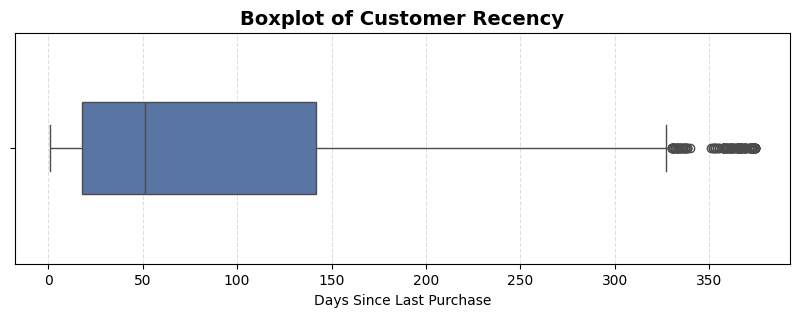

In [ ]:
#Box Plot
plt.figure(figsize=(10,3))
sns.boxplot(x=rfm["Recency"], width=0.4,color="#4C72B0")
plt.xlabel("Days Since Last Purchase")
plt.title("Boxplot of Customer Recency", fontsize=14, fontweight="bold")
plt.grid(axis="x", linestyle="--",alpha=0.4)
plt.show()

#Interpretation
The histogram shows a positively skewed distribution, indicating that most customers made purchases relatively recently, while fewer customers have been inactive for longer periods. The box plot identifies several high-recency outliers, representing customers who have not purchased for an extended period and may be considered at risk of churn. These findings confirm that Recency is a meaningful behavioural variable for customer segmentation using the RFM approach.

#6.2 Frequency Analysis

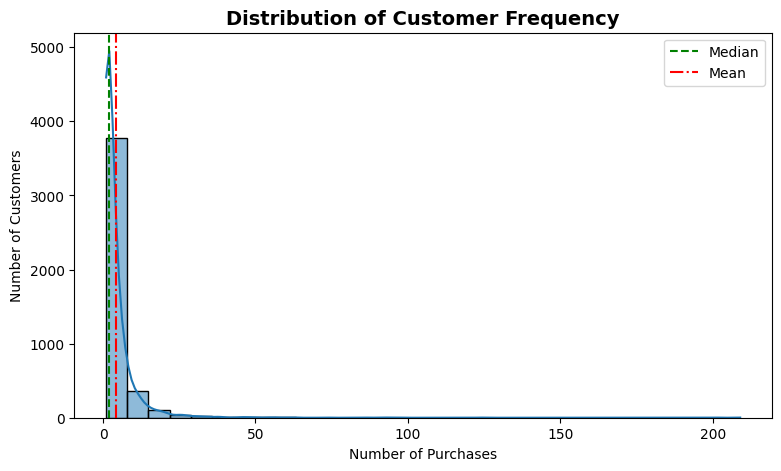

In [ ]:
# histogram of Frequency Distribution
plt.figure(figsize=(9,5))

sns.histplot(rfm["Frequency"], bins=30, kde=True)

plt.axvline(rfm["Frequency"].median(), color="green", linestyle="--", label="Median")
plt.axvline(rfm["Frequency"].mean(), color="red", linestyle="-.", label="Mean")

plt.title("Distribution of Customer Frequency", fontsize=14, fontweight="bold")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

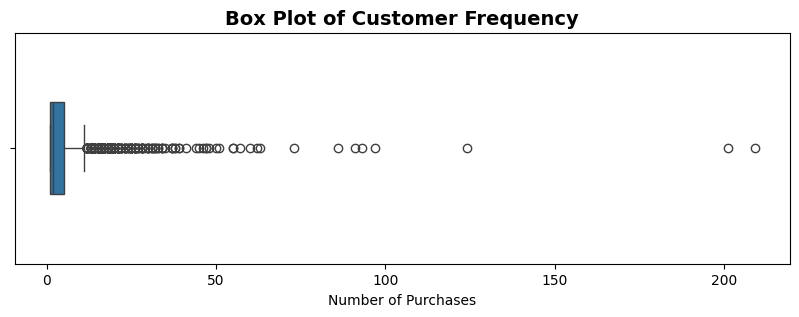

In [ ]:
# Box Plot

plt.figure(figsize=(10,3))
sns.boxplot(x=rfm["Frequency"], width=0.4)
plt.title("Box Plot of Customer Frequency", fontsize=14, fontweight="bold")
plt.xlabel("Number of Purchases")
plt.show()

#Interpretation
The frequency distribution is positively skewed, indicating that most customers made only a small number of purchases during the study period, while a relatively small group of customers purchased much more frequently. The box plot identifies several high-frequency outliers, representing loyal customers with strong repeat purchasing behaviour. These findings demonstrate that Frequency effectively distinguishes occasional buyers from loyal customers, making it an important behavioural variable for customer segmentation and retention strategies within the RFM framework.

#6.3 Monetary Analysis

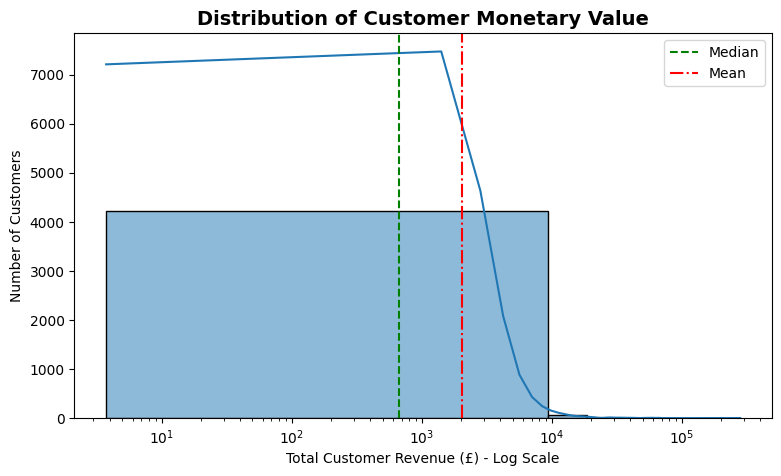

In [ ]:
# Histogram for Monetary Analysis
plt.figure(figsize=(9,5))

sns.histplot(rfm["Monetary"], bins=30, kde=True)

plt.xscale("log")

plt.axvline(rfm["Monetary"].median(), color="green", linestyle="--", label="Median")
plt.axvline(rfm["Monetary"].mean(), color="red", linestyle="-.", label="Mean")

plt.title("Distribution of Customer Monetary Value", fontsize=14, fontweight="bold")
plt.xlabel("Total Customer Revenue (£) - Log Scale")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

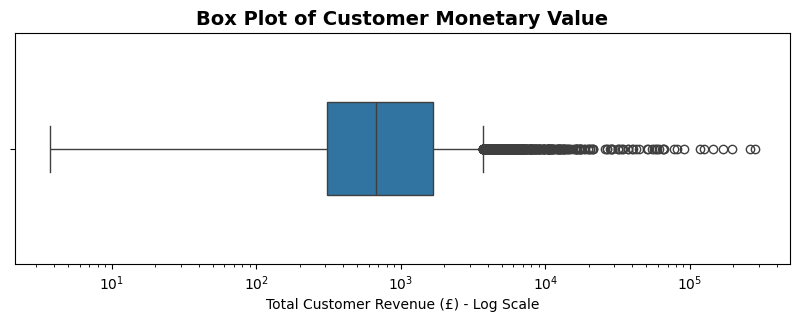

In [ ]:
# Box Plot
plt.figure(figsize=(10,3))

sns.boxplot(x=rfm["Monetary"], width=0.4)

plt.xscale("log")

plt.title("Box Plot of Customer Monetary Value", fontsize=14, fontweight="bold")
plt.xlabel("Total Customer Revenue (£) - Log Scale")

plt.show()

###Interpretation
The monetary distribution is highly positively skewed, indicating that most customers generated relatively low total revenue, while a small proportion contributed substantially higher spending. The box plot highlights several high-value outliers, representing customers with exceptional purchasing value. These findings demonstrate that Monetary effectively distinguishes high-value customers from lower-spending customers, making it a key variable for identifying profitable customer segments and supporting targeted marketing and customer retention strategies within the RFM framework.

#7. RFM Scoring
RFM scores were assigned using quintile-based scoring to standardize customer purchasing behaviour. Customers with more recent purchases received higher Recency scores, while customers with higher purchase frequency and greater spending received higher Frequency and Monetary scores. The combined RFM score provides an overall measure of customer value for segmentation.

In [ ]:
import pandas as pd

# Recency Score (Lower Recency = Higher Score)
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])

# Frequency Score (Higher Frequency = Higher Score)
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary Score (Higher Monetary = Higher Score)
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

# Total RFM Score
rfm["RFM_Total"] = (
    rfm["R_Score"].astype(int)
    + rfm["F_Score"].astype(int)
    + rfm["M_Score"].astype(int)
)

# Combined RFM Score
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,RFM_Score
CustomerID,,,,,,,,
"12,346.00",326,1,"77,183.60",1,1,5,7,115
"12,347.00",2,7,"4,310.00",5,5,5,15,555
"12,348.00",75,4,"1,797.24",2,4,4,10,244
"12,349.00",19,1,"1,757.55",4,1,4,9,414
"12,350.00",310,1,334.40,1,1,2,4,112


#8. Customer Segmentation
Customer segments were created based on the total RFM score to group customers with similar purchasing behaviour. These segments provide a simple and interpretable way to support targeted marketing, customer retention, and business decision-making.

In [ ]:

def customer_segment(score):

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 8:
        return "Potential Loyalists"

    elif score >= 6:
        return "At Risk"

    else:
        return "Lost Customers"

rfm["Customer_Segment"] = rfm["RFM_Total"].apply(customer_segment)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,RFM_Score,Customer_Segment
CustomerID,,,,,,,,,
"12,346.00",326,1,"77,183.60",1,1,5,7,115,At Risk
"12,347.00",2,7,"4,310.00",5,5,5,15,555,Champions
"12,348.00",75,4,"1,797.24",2,4,4,10,244,Loyal Customers
"12,349.00",19,1,"1,757.55",4,1,4,9,414,Potential Loyalists
"12,350.00",310,1,334.40,1,1,2,4,112,Lost Customers


In [ ]:
# Customer Segment Summary
segment_summary = (
    rfm["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Customer Segment","Number of Customers"]

segment_summary

,Customer Segment,Number of Customers
0,Loyal Customers,1010
1,Champions,933
2,Lost Customers,881
3,At Risk,803
4,Potential Loyalists,711


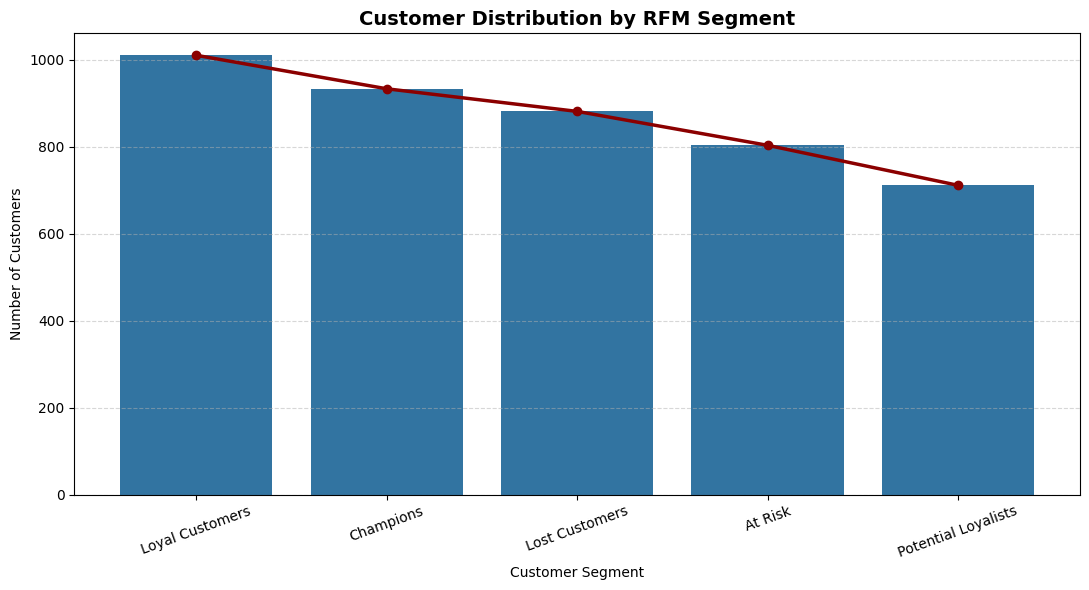

In [ ]:
plt.figure(figsize=(11,6))

sns.countplot(
    data=rfm,
    x="Customer_Segment",
    order=rfm["Customer_Segment"].value_counts().index
)
counts = rfm["Customer_Segment"].value_counts()

plt.plot(
    range(len(counts)),
    counts.values,
    marker="o",color="darkred",
    #linestyle="dashed",
    linewidth=2.5)
plt.title("Customer Distribution by RFM Segment",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

###Interpretation
The RFM segmentation successfully classified customers into five behavioural groups based on their purchasing patterns. Loyal Customers and Champions represent the highest-value customer segments, while At Risk and Lost Customers indicate opportunities for targeted retention strategies. These results demonstrate that the RFM model effectively supports customer segmentation and provides valuable insights for data-driven marketing and customer relationship management.

#9. Model Evaluation

##9.1 Segment-Level RFM Summary

In [ ]:
# Average RFM values by customer segment

segment_profile = rfm.groupby("Customer_Segment")[["Recency","Frequency","Monetary"]].mean().round(2)

segment_profile

,Recency,Frequency,Monetary
Customer_Segment,,,
At Risk,111.94,1.45,535.45
Champions,14.64,11.75,"6,689.76"
Lost Customers,224.80,1.05,228.86
Loyal Customers,43.41,3.86,"1,389.11"
Potential Loyalists,78.74,2.23,859.46


##9.2 Revenue by Customer Segmentation

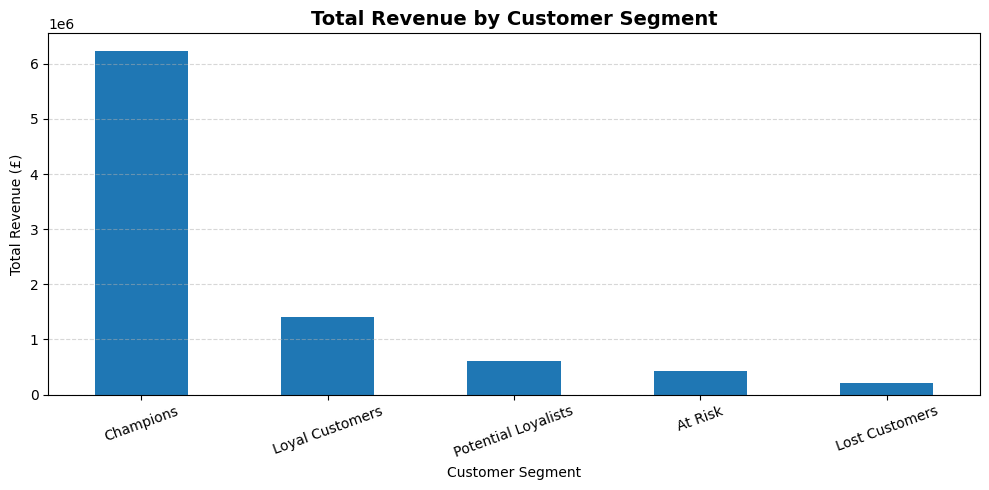

In [ ]:
# Total Revenue by Customer Segment

revenue_segment = rfm.groupby("Customer_Segment")["Monetary"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
revenue_segment.plot(kind="bar")
plt.title("Total Revenue by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (£)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##9.3 Validation and Data Integrity

The RFM approach is a descriptive customer segmentation technique rather than a supervised predictive model. Therefore, a train-test split was not required because no prediction was performed. Customer scores were calculated using historical transaction data only, ensuring that no future information was incorporated into the analysis. This prevents data leakage and maintains the integrity of the customer segmentation process.

### Interpretation

The segment-level analysis demonstrates clear differences in customer purchasing behaviour across the five RFM groups. Champions and Loyal Customers show stronger purchasing activity and higher monetary value, while At Risk and Lost Customers exhibit lower engagement. These results indicate that the RFM model successfully differentiates customer value and provides meaningful insights for targeted business strategies.

# 10. Conclusion

The initial results demonstrate that the proposed analytical pipeline was successfully implemented, from data loading and preprocessing to RFM customer segmentation. The RFM model effectively differentiated customers based on purchasing behaviour and produced meaningful customer segments that support the research objectives. These initial findings confirm the feasibility of the proposed approach and provide a strong foundation for the final project, where customer segments will be further evaluated and translated into business recommendations.